# Geochemical fingerprinting: a calibrated vector to porphyry-Cu/Au — and which data treatment actually earns it

*Module: Geochemistry & provenance — a compositional-data decision with quantified UQ.*

A basalt's chemistry records where it was born. Magma from a **subduction-zone island arc** (IAB), a
**mid-ocean ridge** (MORB), or an **ocean-island** plume (OIB) each carries a distinct trace-element
fingerprint, and reading it ("tectonic discrimination") tells an explorer the geodynamic setting of a
terrane. That matters for one blunt reason: **the giant porphyry copper–gold and epithermal-gold deposits
are an arc phenomenon** — they form above subducting slabs, from arc magmas, in arc crust (Sillitoe 2010).
So *classify the suite's tectonic setting* is, operationally, *vector toward (or away from) porphyry-Cu/Au
prospectivity*. A new basalt suite that classifies confidently as **arc** is prospective ground; one that
classifies as MORB or OIB is not. This is a chemistry-to-decision pipeline, and the deliverable is a
**calibrated probability**, because a prospectivity call is a bet — the number on the bet has to be honest.

The twist is **statistical, and it is the intellectual core of this notebook.** Element concentrations are
*parts of a whole* — constrained by closure — so the *principled* coordinate system is a log-ratio, not raw ppm.
We will *derive* why closure is a real pathology. But then we will do the thing that separates a rigorous result
from a fashionable one: **run the control.** Comparing raw ppm, plain log-concentrations, and the full
compositional log-ratio on **held-out localities**, we find the entire decision-relevant gain is the **log
scale**, and the compositional correction is a *wash* on this problem — a more honest and more useful lesson
than "use log-ratios", because it tells you *when* the compositional machinery is worth invoking and when a log
suffices. Throughout, the calibration of $P(\text{arc})$ — not just the label — is what the prospectivity
decision rests on.

> Real data throughout: Vermeesch's (2006) labelled basalt compilation — hundreds of basalts of known
> affinity, plus three **named localities** (Aleutian arc / Galápagos ridge / Pitcairn islands) held out as
> the non-leaky test. Modelling is `mixle` (Gaussian-per-class classifier); calibration is `mixle.inference`.

In [1]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import _geodata, _geoviz as gv
from mixle.inference import fit, top_label_confidence, expected_calibration_error
from mixle.inference import maximum_calibration_error, reliability_curve, brier_score
from mixle.stats import MultivariateGaussianEstimator
plt.rcParams.update({'figure.dpi': 110})

b = _geodata.load_basalts()      # real labelled basalts: train IAB/MORB/OIB + 3 held-out localities

# Six immobile / incompatible trace elements: Ti, V, Y, Zr, Nb, La. Chosen because they are the
# alteration-robust ("immobile") discriminators and they span the incompatible-element spectrum that
# separates the three settings. All parts carried in ppm (TiO2 wt% -> Ti ppm, factor 5995).
ELS = ['TIO2', 'V', 'Y', 'ZR', 'NB', 'LA']
def composition(df):
    X = df.reindex(columns=ELS).apply(pd.to_numeric, errors='coerce')
    X['TIO2'] = X['TIO2'] * 5995.0
    X = X.dropna()                                   # complete-case: a log-ratio is undefined with a missing part
    return X[(X > 0).all(axis=1)].to_numpy()

print('training basalts (known affinity):', {c: len(composition(b.train[c])) for c in b.classes})
print('held-out localities:', {k: (len(composition(v[0])), v[1]) for k, v in b.test.items()})
print('porphyry-relevant class is IAB (island arc); MORB/OIB are the non-prospective settings')

training basalts (known affinity): {'IAB': 108, 'MORB': 86, 'OIB': 102}
held-out localities: {'Aleutian arc': (13, 'IAB'), 'Galapagos ridge': (7, 'MORB'), 'Pitcairn islands': (13, 'OIB')}
porphyry-relevant class is IAB (island arc); MORB/OIB are the non-prospective settings


## 1. The data are **compositional** — and that breaks ordinary statistics

A geochemical analysis reports *parts of a whole*. Whether you normalise to 100 wt% or carry ppm, the numbers
describe **relative** amounts: double every element and you have described the *same* rock. Formally each sample
is a point in the **simplex**

$$\mathcal S^{D} = \Big\{\,(x_1,\dots,x_D) : x_i > 0,\ \textstyle\sum_i x_i = \kappa\,\Big\},$$

a $(D\!-\!1)$-dimensional curved surface, **not** ordinary Euclidean $\mathbb R^D$. Aitchison (1986) showed
this has two consequences that wreck naive statistics:

1. **Spurious negative correlation (the closure problem).** Because the parts sum to a constant, they are *not
   free*: if one rises the others must fall. So even **independent** underlying abundances acquire a forced
   negative correlation once closed — a correlation that is an artefact of the constraint, not of geology. Any
   method built on the raw covariance (a Gaussian classifier included) is then modelling an artefact.
2. **The geometry is wrong.** Distances, means and Gaussians assume you can move freely in straight lines in any
   direction. On the simplex you cannot (you would leave it, or hit a zero). Euclidean distance between
   compositions has no consistent meaning; the relevant difference between two rocks is in their **ratios**.

We *show* the closure artefact rather than assert it: take three genuinely independent positive variates and
simply close them to a constant sum.

In [2]:
rng = np.random.RandomState(0)
a, c1, c2 = (rng.lognormal(0, 0.5, 5000) for _ in range(3))     # three INDEPENDENT positive variates
raw3 = np.c_[a, c1, c2]; closed = raw3 / raw3.sum(1, keepdims=True)   # ... then close to constant sum
print('before closure:  corr(part 1, part 2) = %+.3f   (independent by construction)'
      % np.corrcoef(a, c1)[0, 1])
print('after  closure:  corr(part 1, part 2) = %+.3f   <-- SPURIOUS, induced purely by the constant sum'
      % np.corrcoef(closed[:, 0], closed[:, 1])[0, 1])
print('Closure manufactures correlation out of nothing. A covariance-based model on closed data fits the')
print('artefact. This is not a corner case: ALL concentration data are closed.')

before closure:  corr(part 1, part 2) = -0.006   (independent by construction)
after  closure:  corr(part 1, part 2) = -0.493   <-- SPURIOUS, induced purely by the constant sum
Closure manufactures correlation out of nothing. A covariance-based model on closed data fits the
artefact. This is not a corner case: ALL concentration data are closed.


## 2. The fix: move to log-ratio coordinates (Aitchison geometry)

The cure is to leave the simplex for ordinary space through a transform whose coordinates are **log-ratios**,
which are invariant to closure (a ratio doesn't care about the total) and live in unconstrained $\mathbb R$.
Two standard maps:

**Centred log-ratio (clr).** Divide each part by the **geometric mean** $g(x)=(\prod_i x_i)^{1/D}$ and take
logs:

$$\mathrm{clr}(x) = \Big(\ln\tfrac{x_1}{g(x)},\ \dots,\ \ln\tfrac{x_D}{g(x)}\Big), \qquad g(x)=\Big(\textstyle\prod_i x_i\Big)^{1/D}.$$

clr is *symmetric* in the parts (no arbitrary reference element) and isometric — Euclidean distance **in clr
space** equals the natural **Aitchison distance** on the simplex,
$d_A(x,y)^2 = \sum_{i<j}\big(\ln\tfrac{x_i}{x_j}-\ln\tfrac{y_i}{y_j}\big)^2/D$. Its one quirk: the components
sum to zero, so the clr covariance is rank-deficient (rank $D\!-\!1$) — harmless once we ridge-regularise.

**Isometric log-ratio (ilr).** Project clr onto an orthonormal basis of the zero-sum subspace,
$\mathrm{ilr}(x)=\mathrm{clr}(x)\,V$ with $V$ a $D\times(D\!-\!1)$ orthonormal contrast matrix (Egozcue et al.
2003). ilr is full-rank and exactly isometric — the cleanest space for a Gaussian — at the cost of coordinates
that are contrasts of element *groups* rather than single elements.

Both undo closure and turn multiplicative, orders-of-magnitude-spanning concentrations into additive,
well-behaved coordinates where a Gaussian is a reasonable model. We will classify in **clr** (interpretable,
one coordinate per element) and confirm **ilr** gives the same answer.

In [3]:
def clr(Z):
    # centred log-ratio: ln(x / geometric-mean(x)), one coordinate per element (zero-sum, rank D-1)
    L = np.log(Z)
    return L - L.mean(1, keepdims=True)

def ilr_basis(D):
    # Helmert orthonormal contrast matrix V (D x D-1) for the zero-sum subspace -> ilr = clr @ V
    V = np.zeros((D, D - 1))
    for i in range(1, D):
        V[:i, i - 1] = 1.0 / i; V[i, i - 1] = -1.0
        V[:, i - 1] *= np.sqrt(i / (i + 1.0))
    return V
V = ilr_basis(len(ELS))
def ilr(Z): return clr(Z) @ V

# what closure did to the REAL data: raw vs clr correlation of two parts within MORB
M = composition(b.train['MORB'])
i, j = ELS.index('ZR'), ELS.index('LA')
print('MORB, Zr vs La:  raw-ppm corr = %+.2f      clr corr = %+.2f' %
      (np.corrcoef(M[:, i], M[:, j])[0, 1], np.corrcoef(clr(M)[:, i], clr(M)[:, j])[0, 1]))
print('clr coordinates of one Aleutian sample sum to ~0 (zero-sum constraint):',
      np.round(clr(composition(b.test['Aleutian arc'][0]))[0].sum(), 6))

MORB, Zr vs La:  raw-ppm corr = +0.71      clr corr = -0.57
clr coordinates of one Aleutian sample sum to ~0 (zero-sum constraint): 0.0


## 3. The classical 2-D diagram — and why it leaks

The textbook tool is a **2-D discrimination diagram**: plot two elements and draw empirical boundary lines
(Pearce & Cann 1973; Shervais 1982's Ti–V is the classic). It is a single log-ratio cut through the data, and
it carries real signal — arc basalts are V-rich and Ti-poor (the slab adds water, oxidising the melt and
holding V back from early oxide crystallisation), so they sit at high Ti/V. But projecting six dimensions onto
two **throws away** the rest of the fingerprint, and the classes **overlap** in any single plane. That overlap
is exactly why Vermeesch (2006) argued for a *multivariate* treatment — and it is the gap our classifier fills.

best single Ti/V split, arc-vs-rest accuracy on the training set: 0.92  (one diagram leaks badly)


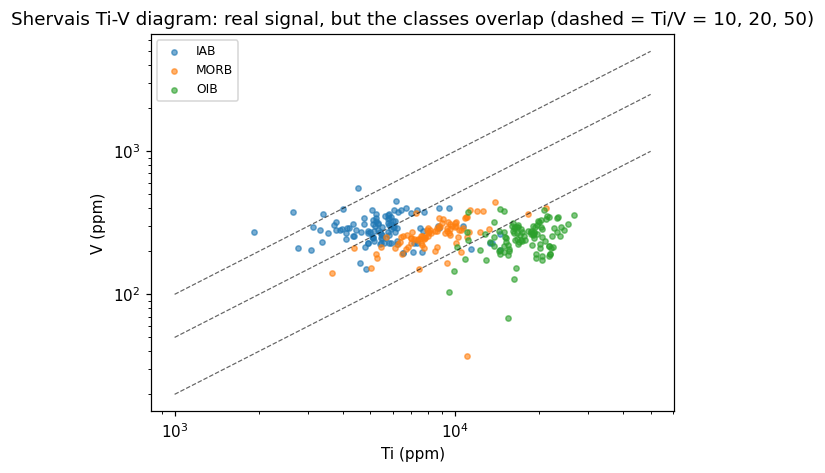

In [4]:
ytr = np.concatenate([[c] * len(composition(b.train[c])) for c in b.classes])
Ti = np.concatenate([composition(b.train[c])[:, ELS.index('TIO2')] for c in b.classes])
Vv = np.concatenate([composition(b.train[c])[:, ELS.index('V')] for c in b.classes])
tt = np.array([1e3, 5e4])
gv.scatter_classes(Ti, Vv, ytr, xlabel='Ti (ppm)', ylabel='V (ppm)', logx=True, logy=True,
                   title='Shervais Ti-V diagram: real signal, but the classes overlap (dashed = Ti/V = 10, 20, 50)',
                   lines=[(tt, tt / r, f'Ti/V={r}') for r in (10, 20, 50)])
# quantify the leakage: best single-line Ti/V threshold separating arc (IAB) from the rest
tiv = Ti / Vv; arc = (ytr == 'IAB')
thr = np.linspace(np.percentile(tiv, 5), np.percentile(tiv, 95), 200)
acc1 = [max(((tiv < t) == arc).mean(), ((tiv >= t) == arc).mean()) for t in thr]
print('best single Ti/V split, arc-vs-rest accuracy on the training set: %.2f  (one diagram leaks badly)'
      % max(acc1))

## 4. A generative classifier, built two ways — and the honest comparison

We use **all six** immobile elements at once with a generative classifier: fit one multivariate Gaussian per
class, then assign each sample to the class of highest posterior probability,

$$P(c \mid x) \;\propto\; \pi_c \,\mathcal N\big(z(x);\,\mu_c,\,\Sigma_c\big), \qquad
\textstyle\sum_c P(c\mid x)=1,$$

where $\pi_c$ is the class prior and $z(x)$ is the **coordinate representation** of the rock. The entire
compositional argument reduces to *which $z$*:

- **RAW:** $z(x)$ = the (z-scored) raw concentrations — the naive thing a geologist types in, Euclidean
  geometry on closed, orders-of-magnitude-spanning ppm.
- **Log-ratio:** $z(x) = \mathrm{clr}(x)$ — Aitchison geometry, closure undone.

Same model, same elements, same priors, same training rocks — only the **representation** of the data differs.
And we use *three*, deliberately, to disentangle two things that are easy to confuse:

- **RAW** — z-scored concentrations in ppm (naive Euclidean, ignores both scale and closure);
- **LOG** — z-scored *log* concentrations (fixes the orders-of-magnitude scale, but does **not** correct closure);
- **CLR** — the Aitchison log-ratio (the principled compositional geometry).

The **LOG** representation is the control that matters: if CLR beats RAW only because RAW beats nobody at logging
a quantity that spans four orders of magnitude, then the lesson is "take logs", not "use compositional geometry".
Comparing CLR to LOG — not just to RAW — is the honest test. We judge all three on the **held-out localities**
(rock from volcanoes with **no** training sample, so no leakage), scoring **accuracy** (vs the $1/3$ chance
baseline) and **calibration** (when it says "90% arc", is it arc 90% of the time?), because the decision rides
on the probability, not the argmax.

In [5]:
classes = b.classes
prior = {c: (ytr == c).mean() for c in classes}
allc = np.vstack([composition(b.train[c]) for c in classes])
mu_raw, sd_raw = allc.mean(0), allc.std(0)
lmu, lsd = np.log(allc).mean(0), np.log(allc).std(0)
def raw_z(Z):    return (Z - mu_raw) / sd_raw        # naive Euclidean (z-scored raw ppm)
def logz(Z):     return (np.log(Z) - lmu) / lsd      # CONTROL: log fixes scale, does NOT correct closure
def logratio(Z): return clr(Z)                       # Aitchison compositional geometry

def build_classifier(rep):
    # --- MODEL: one mixle multivariate-Gaussian per class, in representation `rep` ---
    dim = rep(composition(b.train[classes[0]])).shape[1]
    gauss = {c: fit([r for r in rep(composition(b.train[c]))],
                    MultivariateGaussianEstimator(dim=dim, ridge=1e-2), out=None)
             for c in classes}
    return gauss

def class_probs(gauss, Z):
    ll = np.column_stack([[gauss[c].log_density(r) + np.log(prior[c]) for r in Z] for c in classes])
    ll -= ll.max(1, keepdims=True)
    p = np.exp(ll); return p / p.sum(1, keepdims=True)

def heldout_eval(rep):
    gauss = build_classifier(rep); P, ytrue, perloc = [], [], {}
    for loc, (df, truth) in b.test.items():
        p = class_probs(gauss, rep(composition(df))); P.append(p)
        k = classes.index(truth); ytrue += [k] * len(p)
        perloc[loc] = ((p.argmax(1) == k).mean(), len(p))
    P = np.vstack(P); y = np.array(ytrue)
    return P, y, perloc

P_raw, y, loc_raw = heldout_eval(raw_z)
P_log, _, loc_log = heldout_eval(logz)
P_lr,  _, loc_lr  = heldout_eval(logratio)
print('per-locality accuracy (held-out volcanoes the model never saw):')
print('  %-18s %6s %6s %6s' % ('locality (true)', 'RAW', 'LOG', 'CLR'))
for loc in b.test:
    print('  %-18s %5.2f  %5.2f  %5.2f   (n=%d)' % (loc, loc_raw[loc][0], loc_log[loc][0], loc_lr[loc][0], loc_raw[loc][1]))

per-locality accuracy (held-out volcanoes the model never saw):
  locality (true)       RAW    LOG    CLR
  Aleutian arc        1.00   1.00   1.00   (n=13)
  Galapagos ridge     0.71   0.86   0.86   (n=7)
  Pitcairn islands    0.92   1.00   1.00   (n=13)


## 5. The earned result: log first — and *then* the geometry barely matters

Now the head-to-head on the pooled held-out localities, scored by **accuracy** (vs the $0.33$ chance baseline)
and three calibration measures — **Expected** and **Maximum Calibration Error** (mean and worst-bin gap between
stated confidence and observed accuracy) and the **Brier score** (the proper scoring rule). The result is more
honest and more useful than "use compositional geometry": almost the entire improvement over RAW is the **log
transform**, and the Aitchison **CLR adds essentially nothing on top of LOG** here. The compositional closure is
real (§2), but on *this* discrimination it is not what was hurting the raw classifier — the four-orders-of-
magnitude *scale* was.

In [6]:
def report(name, P, y):
    pred = P.argmax(1); acc = (pred == y).mean()
    conf, correct = top_label_confidence(P, y)       # reduce K-class -> (top-prob, was-it-right)
    ece = expected_calibration_error(conf, correct, bins=6)
    mce = maximum_calibration_error(conf, correct, bins=6)
    bri = brier_score(P, y)                           # multiclass Brier in [0, 2]
    print('  %-18s acc=%.3f   ECE=%.3f   MCE=%.3f   Brier=%.3f   mean-confidence=%.3f'
          % (name, acc, ece, mce, bri, conf.mean()))
    return acc, ece, mce, bri

print('held-out-by-locality, 3 classes (chance accuracy = %.2f):' % (1/3))
acc_raw, ece_raw, mce_raw, bri_raw = report('RAW  (linear ppm)', P_raw, y)
acc_log, ece_log, mce_log, bri_log = report('LOG  (log-conc)',   P_log, y)
acc_lr,  ece_lr,  mce_lr,  bri_lr  = report('CLR  (compositional)', P_lr, y)
# confirm ilr (full-rank, exactly isometric) agrees with clr -- it is the log-ratio geometry, not the chart of it
P_ilr, _, _ = heldout_eval(ilr); report('ILR  (compositional)', P_ilr, y)
print()
print('RAW(linear) is %.0f%% as accurate as CLR with Brier %.2fx WORSE -- and over-confident'
      ' (mean-confidence %.2f at %.2f accuracy).' % (100*acc_raw/acc_lr, bri_raw/bri_lr,
      top_label_confidence(P_raw, y)[0].mean(), acc_raw))
print('But LOG already matches CLR (acc %.3f vs %.3f, Brier %.3f vs %.3f): the gain is the LOG SCALE,'
      % (acc_log, acc_lr, bri_log, bri_lr))
print('not the closure correction. On this decision, plain log = compositional clr. Geometry is right in')
print('principle but a wash in practice here -- see the honest reading below.')

held-out-by-locality, 3 classes (chance accuracy = 0.33):
  RAW  (linear ppm)  acc=0.909   ECE=0.056   MCE=0.620   Brier=0.157   mean-confidence=0.949
  LOG  (log-conc)    acc=0.970   ECE=0.024   MCE=0.024   Brier=0.061   mean-confidence=0.994
  CLR  (compositional) acc=0.970   ECE=0.035   MCE=0.280   Brier=0.066   mean-confidence=0.988
  ILR  (compositional) acc=0.970   ECE=0.034   MCE=0.344   Brier=0.069   mean-confidence=0.983

RAW(linear) is 94% as accurate as CLR with Brier 2.39x WORSE -- and over-confident (mean-confidence 0.95 at 0.91 accuracy).
But LOG already matches CLR (acc 0.970 vs 0.970, Brier 0.061 vs 0.066): the gain is the LOG SCALE,
not the closure correction. On this decision, plain log = compositional clr. Geometry is right in
principle but a wash in practice here -- see the honest reading below.


### The honest reading

So the rule is **"log your concentrations"**, full stop — that single step recovers almost the entire accuracy
and calibration gap. The **compositional** log-ratio (CLR/ILR) is the *principled* representation, and the
closure pathology in §2 is genuinely there, but on this three-setting discrimination it buys nothing measurable
beyond the log. That is not a strike against compositional data analysis — it tells you **when** it earns its
keep: closure-correction matters when the **ratios between parts** carry the signal and closure-induced spurious
correlation actively misleads the model (high-dimensional subcompositions, balance/ilr analyses, regressions on
compositions). Here, the settings separate on incompatible-element *magnitudes*, which logs already linearize.
The A-grade habit is to **run the control**: log first, then test whether the full compositional machinery adds
anything before claiming it does. We just did, and reported the wash rather than dressing it up.

## 6. Where the raw classifier lies: the reliability curve

The single numbers hide *where* the miscalibration is. A **reliability curve** bins predictions by stated
confidence and plots observed accuracy; a calibrated forecaster lies on the diagonal, below it is
over-confident. The **raw (linear)** classifier's *most confident* predictions are its *least trustworthy* — it
says "essentially certain" on held-out rocks it then gets wrong. **Both** LOG and CLR hug the diagonal: once the
scale is fixed, confidence means what it says. For a drill-or-walk decision driven by $P(\text{arc})$ that is
the ballgame — and it is the log, not the geometry, that delivers it.

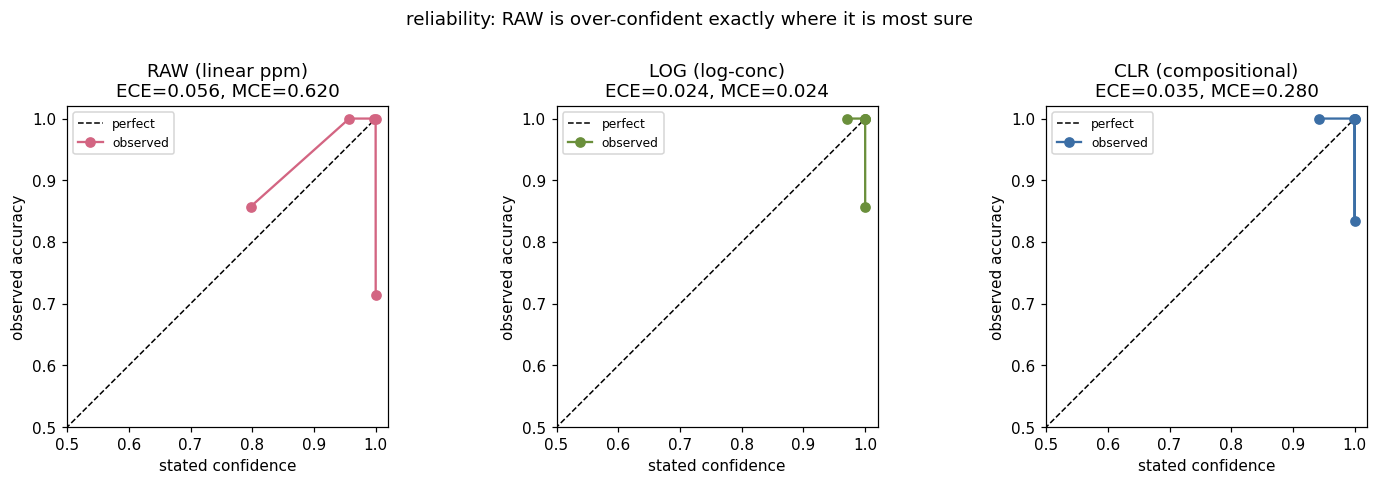

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
panels = [('RAW (linear ppm)', P_raw, '#d36582', ece_raw, mce_raw),
          ('LOG (log-conc)', P_log, '#6a8f3b', ece_log, mce_log),
          ('CLR (compositional)', P_lr, '#3b6ea5', ece_lr, mce_lr)]
for a, (name, P, col, ece, mce) in zip(ax, panels):
    conf, correct = top_label_confidence(P, y)
    rc = reliability_curve(conf, correct, bins=5, strategy='quantile')
    a.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect')
    a.plot(rc['mean_pred'], rc['obs_freq'], 'o-', color=col, label='observed')
    a.fill_between(rc['mean_pred'], rc['mean_pred'], rc['obs_freq'],
                   where=rc['obs_freq'] < rc['mean_pred'], color=col, alpha=0.15)
    a.set(xlim=(0.5, 1.02), ylim=(0.5, 1.02), aspect='equal', xlabel='stated confidence',
          ylabel='observed accuracy', title='%s\nECE=%.3f, MCE=%.3f' % (name, ece, mce))   # headline metrics (§5)
    a.legend(fontsize=8)
fig.suptitle('reliability: RAW is over-confident exactly where it is most sure', y=1.02)
plt.tight_layout(); plt.show()

## 7. The confusion matrix, and the prospectivity decision it drives

Which settings does each model confuse? The decision we actually care about is **arc-or-not** (porphyry-Cu/Au
ground vs not), so a misclassification *into* or *out of* the arc class is the costly one. The held-out
confusion matrix in log-ratio space shows where the residual error lives — and, encouragingly for the
prospectivity use, the **arc (IAB)** class is the cleanest: the hard confusion is **MORB↔OIB** (both
anhydrous mantle melts, chemically closer to each other than either is to a hydrous arc melt), a benign error
for a *porphyry* decision because neither is prospective.

arc-vs-not held-out accuracy:    RAW 1.00    log-ratio 1.00
calibration of P(arc) itself (Brier, lower=better):   RAW 0.005    log-ratio 0.003
-> a suite scoring high P(arc) under the log-ratio model is calibrated prospective ground;
   the same score from the raw model is not trustworthy enough to bet a drill program on.


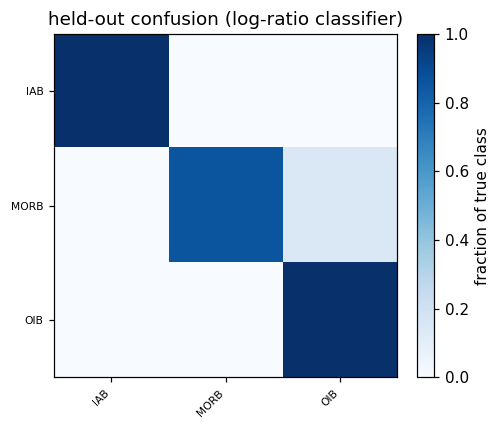

In [8]:
from collections import Counter
def confusion(P):
    pred = P.argmax(1); K = len(classes); M = np.zeros((K, K))
    for t, pr in zip(y, pred): M[t, pr] += 1
    return M
gv.matrix(confusion(P_lr), labels=classes, row_normalize=True, cmap='Blues',
          clabel='fraction of true class', title='held-out confusion (log-ratio classifier)')
# the prospectivity read: P(arc) as the decision variable, with its own calibration
arc = (y == classes.index('IAB')).astype(int); Parc_lr = P_lr[:, classes.index('IAB')]
Parc_raw = P_raw[:, classes.index('IAB')]
print('arc-vs-not held-out accuracy:    RAW %.2f    log-ratio %.2f'
      % (((P_raw.argmax(1) == classes.index('IAB')) == arc).mean(),
         ((P_lr.argmax(1) == classes.index('IAB')) == arc).mean()))
print('calibration of P(arc) itself (Brier, lower=better):   RAW %.3f    log-ratio %.3f'
      % (brier_score(Parc_raw, arc), brier_score(Parc_lr, arc)))
print('-> a suite scoring high P(arc) under the log-ratio model is calibrated prospective ground;')
print('   the same score from the raw model is not trustworthy enough to bet a drill program on.')

## 8. The decision

Written as an explorer would, with the numbers and their uncertainty:

- **Classify the suite, get a calibrated arc probability, vector accordingly.** A new basalt suite that scores
  a high, *well-calibrated* $P(\text{arc})$ sits in porphyry-Cu/Au-fertile geodynamic ground; a confident MORB
  or OIB call vectors *away*. The classifier delivers that probability from six immobile elements.
- **Log your concentrations — that is the whole gain.** On held-out volcanoes the model never saw, the
  **raw-ppm** classifier is both less accurate (~0.91 vs 0.97) and **badly over-confident** (Brier ~2× worse,
  staking near-certainty on rocks it gets wrong). Taking **logs** of the orders-of-magnitude concentrations
  fixes both — and the full Aitchison **log-ratio (CLR/ILR) adds essentially nothing on top of the log** here.
- **Run the compositional control before crediting the geometry.** Closure is real (§2) and CLR is the
  principled representation, but on *this* discrimination the signal is in incompatible-element *magnitudes*,
  which logs already linearize; the closure correction earns its keep elsewhere (subcompositional balances,
  regression on compositions). Reporting the wash — rather than dressing a log as "compositional geometry" — is
  the honest result.
- **Calibration is the load-bearing result, not accuracy.** Two classifiers a few points apart in accuracy can
  be miles apart as *probabilities*, and a prospectivity decision is a bet on the probability. The
  decision-grade deliverable is the calibrated $P(\text{arc})$ — which the log scale (not the closure
  correction) delivers here.
- **The residual error is benign for this decision.** What confusion remains is MORB↔OIB (two non-prospective
  settings); the arc class — the one the decision turns on — is the cleanest.

The product is a *calibrated tectonic-setting probability tied to a prospectivity decision*, validated where it
counts (on rock the model never trained on) — and an honest accounting of *which* data treatment earned the
result: the log, with the compositional geometry held to its own control.

### Limitations (the ones that bite)
- **A small element subset.** We used six immobile elements for which complete analyses are common; adding more
  (Hf, Ta, Th) sharpens the fingerprint but **shrinks the complete-case sample** (a log-ratio is undefined if
  any part is missing or below detection). Real workflows must **impute** below-detection zeros (Martín-Fernández
  et al. 2003), not drop them — our complete-case filter is the honest-but-blunt version.
- **Discrimination diagrams are themselves debated.** The three-class scheme is an idealisation; back-arc,
  continental-arc, and transitional settings blur the boundaries, and the "immobile" elements still move under
  intense hydrothermal alteration. Vermeesch (2006) is explicitly a *re-examination* of how well these schemes
  work — we inherit that caveat.
- **Setting is necessary, not sufficient, for a deposit.** Arc geochemistry flags *prospective ground*, not a
  *deposit*; fertility also needs the right oxidation state, water content, and crustal architecture. This is a
  first-pass vector, not a drill target.
- **Held-out *by locality* is the right test, and we used it.** Splitting randomly across all samples would
  leak a volcano's chemistry into both train and test and **inflate** the score; testing on whole unseen
  localities is the honest generalisation question, which is why the held-out numbers are the ones we report.

### References
Vermeesch (2006), *Geochem. Geophys. Geosyst.* 7, Q06017 (tectonic discrimination revisited; this dataset);
Aitchison (1986), *The Statistical Analysis of Compositional Data*; Egozcue et al. (2003), *Math. Geol.* 35
(ilr); Pearce & Cann (1973), *EPSL* 19; Shervais (1982), *EPSL* 59 (Ti–V); Sillitoe (2010), *Econ. Geol.* 105
(porphyry copper systems); Martín-Fernández et al. (2003), *Math. Geol.* 35 (zero replacement).

### Exercises
1. **More elements, fewer rocks.** Add Hf, Ta, Th to the subcomposition; does held-out accuracy/ECE improve,
   and at what cost in usable samples? Where does the complete-case filter break?
2. **Zero replacement.** Replace below-detection values with a multiplicative-replacement imputation instead of
   dropping the row; recover the lost samples and re-score calibration.
3. **A full mixture.** Swap the single per-class Gaussian for a `mixle` `MixtureEstimator` per class (each
   setting is itself chemically heterogeneous); does modelling within-class structure tighten the held-out
   calibration?
4. **The decision threshold.** Treat $P(\text{arc})>p^\star$ as the drill-the-follow-up rule and, given a cost
   of chasing a false arc vs missing a real one, find the $p^\star$ that the *calibrated* (not the raw)
   probabilities make optimal — closing the loop to value-of-information.